## Recap
In the Stag1, we learned how to preprocess raw text, and create dataloader. We built the multi-head attention whose objective is to produce **contex vector**. The **context vector** is reacher than the input vector in the way that it not only preserve the meaning of the query token, and it also preserves the important of other tokens on the query token. 

We also created the GPT Model which encompasses the transformer.

It's important to note that the output of the model is logits. 

logits is tensor of (seq_size x vocab_size) shape. In gpt-2, the seq_size can go max upto 1024.

**logits** are the raw scores the model assigns to every token in the vocabulary before turning them into probabilities. Think of logits as “how strongly the model prefers each possible next token”, but not normalized yet.

**logits** are passed through a **softmax** function that produces probability distributation of vocabulary in a tensor of (seq_size x vocab_size) shape. The tensor is subquently passed through **argmax** function that picks index of the vocab which has the maximum probability and produces a tensor of shape (seq_size x 1).

These indexes are then passed through tokenizer decoder to produce the text output.

### Depiction of Input to Output map in GPT
For simplicity, we have considered the vocabulary dictionary is of size 7.

![decode](https://camo.githubusercontent.com/f98790fc96dfefdd3e61533ca406f241a893976c8cb7668afbcec178763c45a0/68747470733a2f2f73656261737469616e72617363686b612e636f6d2f696d616765732f4c4c4d732d66726f6d2d736372617463682d696d616765732f636830355f636f6d707265737365642f30342e77656270)

#### Code from Previous Chapter
I have copied here the MODEL code from the previous chapters so that we can train it.

In [36]:
import torch
import torch.nn as nn
import tiktoken
from torch.utils.data import Dataset, DataLoader

tokenizer = tiktoken.get_encoding("gpt2")

GPT2_SMALL_CONFIG = {
    "vocab_size": 50257,        # GPT-2 uses a tokenizer with vocab size of 50,257  (GPT-2 uses Byte Pair Encoder)
    "context_length": 256,      # context_length tells you how many tokens you pass in a sequence. also called sequence length. 
                                #It is 1024 for GPT-2. For simplicity, we use 256 here
    "emb_dim": 768,             # embedding dimension. the vector used by GPT-2 SMALL is of 768 dimension
    "n_heads": 12,              # number of heads in multi-head attention.
    "n_layers": 12,             # 12 number of transformer layers/blocks in gpt-2. Each transformer block has 12 multi-head attention.
    "drop_rate": 0.1,             # dropout rate is used to reduce overfitting
    "qkv_bias": False           # Query-Key-Value bias
}

######################################################################33
# Dataset and dataloader
class GPTDatasetV1(Dataset):
        """Small dataset: tokenize `txt` and yield overlapping (input, target).

        Parameters: `txt` (str), `tokenizer`, `max_length` (int), `stride` (int).
        """
        def __init__(self, txt, tokenizer, max_length, stride):
                self.input_ids = []
                self.target_ids = []

                # Tokenize the entire text
                token_ids = tokenizer.encode(txt, allowed_special={"<|endoftext|>"})

                # Use a sliding window to chunk the book into overlapping sequences of max_length
                for i in range(0, len(token_ids) - max_length, stride):
                        input_chunk = token_ids[i:i + max_length]
                        target_chunk = token_ids[i + 1: i + max_length + 1]
                        self.input_ids.append(torch.tensor(input_chunk))
                        self.target_ids.append(torch.tensor(target_chunk))

        def __len__(self):
                """Return the number of examples available."""
                return len(self.input_ids)

        def __getitem__(self, idx):
                """Return the (input_ids, target_ids) tuple for index `idx`.

                Both elements are 1-D `torch.Tensor` of token ids.
                """
                return self.input_ids[idx], self.target_ids[idx]


def create_dataloader_v1(txt, batch_size=4, max_length=256,
                         stride=128, shuffle=False, drop_last=True, num_workers=0):
    # Initialize the tokenizer
    tokenizer = tiktoken.get_encoding("gpt2")

    # Create dataset
    dataset = GPTDatasetV1(txt, tokenizer, max_length, stride)

    # Create dataloader
    dataloader = DataLoader(
        dataset, batch_size=batch_size, shuffle=shuffle, drop_last=drop_last, num_workers=num_workers)

    return dataloader

__all__ = ["create_dataloader_v1", "GPTDatasetV1"]

##### Multi-head attention (produces context vector)
class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        assert (d_out % num_heads == 0), \
            "d_out must be divisible by num_heads"

        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads # Reduce the projection dim to match desired output dim

        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.out_proj = nn.Linear(d_out, d_out)  # Linear layer to combine head outputs
        self.dropout = nn.Dropout(dropout)
        self.register_buffer(
            "mask",
            torch.triu(torch.ones(context_length, context_length),
                       diagonal=1)
        )

    def forward(self, x):
        b, num_tokens, d_in = x.shape
        # As in `CausalAttention`, for inputs where `num_tokens` exceeds `context_length`,
        # this will result in errors in the mask creation further below.
        # In practice, this is not a problem since the LLM (chapters 4-7) ensures that inputs
        # do not exceed `context_length` before reaching this forward method.

        # print(f"Input Matrix: {x}\n")

        keys = self.W_key(x) # Shape: (b, num_tokens, d_out)
        queries = self.W_query(x)
        values = self.W_value(x)

        # print(f"Queries Weights: {self.W_query}\n")

        # print(f"Queries (after multiplying with weights. 6x3 matrix multiple with 3 x 2 matrix, produces 6 x 2 matrix): {queries}\n")


        # We implicitly split the matrix by adding a `num_heads` dimension
        # Unroll last dim: (b, num_tokens, d_out) -> (b, num_tokens, num_heads, head_dim)
        keys = keys.view(b, num_tokens, self.num_heads, self.head_dim)
        values = values.view(b, num_tokens, self.num_heads, self.head_dim)
        queries = queries.view(b, num_tokens, self.num_heads, self.head_dim)

        # print(f"Queries (after weight split): {queries.shape}\n")
        # print(f"Queries (after weight split): {queries}\n")

        # Transpose: (b, num_tokens, num_heads, head_dim) -> (b, num_heads, num_tokens, head_dim)
        keys = keys.transpose(1, 2)
        queries = queries.transpose(1, 2)
        values = values.transpose(1, 2)

        # Compute scaled dot-product attention (aka self-attention) with a causal mask
        attn_scores = queries @ keys.transpose(2, 3)  # Dot product for each head

        # Original mask truncated to the number of tokens and converted to boolean
        mask_bool = self.mask.bool()[:num_tokens, :num_tokens]

        # Use the mask to fill attention scores
        attn_scores.masked_fill_(mask_bool, -torch.inf)

        attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)
        attn_weights = self.dropout(attn_weights)

        # Shape: (b, num_tokens, num_heads, head_dim)
        context_vec = (attn_weights @ values).transpose(1, 2)

        # Combine heads, where self.d_out = self.num_heads * self.head_dim
        context_vec = context_vec.contiguous().view(b, num_tokens, self.d_out)
        context_vec = self.out_proj(context_vec) # optional projection

        return context_vec
##################################################################################################
# 
# LayerNorm (Layer Normalization) and GELU (Gaussian Error Linear Unit)    
class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        norm_x = (x - mean) / torch.sqrt(var + self.eps)
        return self.scale * norm_x + self.shift
    
# Gaussian Error Linear Unit (GELU) activation function
class GELU(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(
            torch.sqrt(torch.tensor(2.0 / torch.pi)) *
            (x + 0.044715 * torch.pow(x, 3))
        ))
# FeedForward (FFN) layer
class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]),
            GELU(),
            nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"]),
        )

    def forward(self, x):
        return self.layers(x)
    
###################################################################################
### Transformer Block
### Transformer Block is a combination of MultiHeadAttention and FeedForward layers
class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.att = MultiHeadAttention(
            d_in=cfg["emb_dim"],
            d_out=cfg["emb_dim"],
            context_length=cfg["context_length"],
            num_heads=cfg["n_heads"],
            dropout=cfg["drop_rate"],
            qkv_bias=cfg["qkv_bias"])
        self.ff = FeedForward(cfg)
        self.norm1 = LayerNorm(cfg["emb_dim"])
        self.norm2 = LayerNorm(cfg["emb_dim"])
        self.dropout = nn.Dropout(cfg["drop_rate"])

    def forward(self, x):
        # Shortcut connection for attention block
        shortcut = x
        x = self.norm1(x)
        x = self.att(x)  # Shape [batch_size, num_tokens, emb_size]
        x = self.dropout(x)
        x = x + shortcut  # Add the original input back

        # Shortcut connection for feed forward block
        shortcut = x
        x = self.norm2(x)
        x = self.ff(x)
        x = self.dropout(x)
        x = x + shortcut  # Add the original input back

        return x

##########################################################################
# GPT-2 model
# GPT-2 model is a stack of Transformer Blocks    
class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])

        # It stacks 12 transformer blocks together
        self.trf_blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])])

        self.final_norm = LayerNorm(cfg["emb_dim"])
        # print(f"Shape of the final normalization layer output: {self.final_norm.shape}\n")
        # print(f"the final normalization layer output: {self.final_norm}\n")
        self.out_head = nn.Linear(
            cfg["emb_dim"], cfg["vocab_size"], bias=False
        )

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape

        # embedding + psotional embedding takes place here
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))
        x = tok_embeds + pos_embeds  # Shape [batch_size, num_tokens, emb_size]

        # dropout takes place
        x = self.drop_emb(x)

        # transformer blocks are invoked
        x = self.trf_blocks(x)

        # final normalization layer
        x = self.final_norm(x)

        # converts the output to logits which is probability distribution on the vocalbulary (50,257)
        logits = self.out_head(x)

        return logits

#########################################################################
# 
# Text generation
# This function generates text using a simple approach where it samples the next token based on the highest probability 
# It loops over the number of tokens to generate (max_new_tokens) and appends the sampled token to the current context (idx)
def generate_text_simple(model, idx, max_new_tokens, context_size):
    # idx is (batch, n_tokens) array of indices in the current context
    for _ in range(max_new_tokens):

        # Crop current context if it exceeds the supported context size
        # E.g., if LLM supports only 5 tokens, and the context size is 10
        # then only the last 5 tokens are used as context
        idx_cond = idx[:, -context_size:]

        # Get the predictions
        with torch.no_grad():
            logits = model(idx_cond)

        # Focus only on the last time step
        # (batch, n_tokens, vocab_size) becomes (batch, vocab_size)
        logits = logits[:, -1, :]

        # Apply softmax to get probabilities
        probas = torch.softmax(logits, dim=-1)  # (batch, vocab_size)

        # Get the idx of the vocab entry with the highest probability value
        idx_next = torch.argmax(probas, dim=-1, keepdim=True)  # (batch, 1)

        # Append sampled index to the running sequence
        idx = torch.cat((idx, idx_next), dim=1)  # (batch, n_tokens+1)

    return idx

def text_to_token_ids(text, tokenizer):
    encoded = tokenizer.encode(text, allowed_special={'<|endoftext|>'})
    encoded_tensor = torch.tensor(encoded).unsqueeze(0) # add batch dimension
    return encoded_tensor

def token_ids_to_text(token_ids, tokenizer):
    flat = token_ids.squeeze(0) # remove batch dimension
    return tokenizer.decode(flat.tolist())


In [37]:
torch.manual_seed(123)
model = GPTModel(GPT2_SMALL_CONFIG)


start_context = "Every effort moves you"
tokenizer = tiktoken.get_encoding("gpt2")

model.eval() #disables dropout during inference

token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids(start_context, tokenizer),
    max_new_tokens=10,
    context_size=GPT2_SMALL_CONFIG["context_length"]
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you rentingetic wasnم refres RexMeCHicular stren


**Note**: Stage1 provides you the RAW model which predicts the text, but the prediction is inaccurate. This is because the model is yet not trained.

## Training Loop
In this chapter, we implement the training loop and code for basic model evaluation to pretrain an LLM. It follows these steps:

- Model generates text
- Generated Text is evaluated and loss calculated
- Loss is used to calculate the gradiet and readjust the weights.

This goes in a loop until, the loss is within the accepted limit and the model predicts with accuracy.

![training](https://camo.githubusercontent.com/137f57f6192fbcb6627e6ced1b5274c71924774dec18a4dea29b1c156619ef24/68747470733a2f2f73656261737469616e72617363686b612e636f6d2f696d616765732f4c4c4d732d66726f6d2d736372617463682d696d616765732f636830355f636f6d707265737365642f30312e77656270)

## Model Prediction (without training)
Here we will pass a batch of text and see what the model predict. does the prediction match with the target?




![decode](https://camo.githubusercontent.com/f98790fc96dfefdd3e61533ca406f241a893976c8cb7668afbcec178763c45a0/68747470733a2f2f73656261737469616e72617363686b612e636f6d2f696d616765732f4c4c4d732d66726f6d2d736372617463682d696d616765732f636830355f636f6d707265737365642f30342e77656270)

In [38]:
torch.manual_seed(123)

# our input to the model
inputs = torch.tensor([[16833, 3626, 6100],   # ["every effort moves",          #x1
                       [40,    1107, 588]])   #  "I really like"]               #x2

# expected output from the model (targets)
targets = torch.tensor([[3626, 6100, 345  ],  # [" effort moves you",           #y1
                        [1107,  588, 11311]]) #  " really like chocolate"]      #y2

# Here the batch size is 2. 
# Each input sequence in the batch is of length 3, and each target sequence is also of length 3.
# Input shape is batch_size x sequence_length

In [39]:
# model prediction
# pass the inputs through the model to get the logits 
# Step1: model converts the token tensor (batch_size x sequence_length) into embeddings tensor (batch_size x sequence_length x emb_dim)
# Step2: model applies transformer blocks to the embeddings tensor to get the context vector tensor (batch_size x sequence_length x emb_dim)
# Step3: model applies a linear layer to the context vector tensor to get the logits tensor (batch_size x sequence_length x vocab_size)
with torch.no_grad():
  logits = model(inputs)

# pass the logits into softmax to get the probability of each token in the vocabulary
# Step4: it applies softmax to the logits tensor to get the probabilities tensor (batch_size x sequence_length x vocab_size) 
probas = torch.softmax(logits, dim=-1)
print(f"probability distribution tensor shape: {probas.shape}") 

# For every input token, let's find the target token with max probability using "argmax"
# Inputs: [["every effort moves"], ["I really like"]]
# Step5: converts the probabilities tensor (batch_size x sequence_length x vocab_size) into token IDs tensor (batch_size x sequence_length x 1)
# it does so by finding the index of the max value in the vocab_size probabilities distribution.
token_ids = torch.argmax(probas, dim=-1, keepdim=True)
outputs = token_ids.squeeze(2) # remove the last dimension
print("Token IDs:\n", outputs)

probability distribution tensor shape: torch.Size([2, 3, 50257])
Token IDs:
 tensor([[16657,   339, 42826],
        [49906, 29669, 41751]])


In [40]:
# Step6: convert the token IDs to text using the tokenizer
for i in range(len(outputs)):
    print(f"Output text for input {i+1}:\n", token_ids_to_text(outputs[i], tokenizer))


Output text for input 1:
  Armed heNetflix
Output text for input 2:
  pressuring empoweredfaith


**Note**:

Here we envidenced that the model without training produces arbitary output which does not match with the expected target.
This is because the model is not trained yet.

## Loss Function (Cross Entropy)

To train the model, we must know how far the model is from predicting the correct predictions (target). So, here are the steps to calculate the loss.

![loss](https://camo.githubusercontent.com/3d6fb2ee91bebb246351570506a344d7d579fc161084faec6856c0659c815452/68747470733a2f2f73656261737469616e72617363686b612e636f6d2f696d616765732f4c4c4d732d66726f6d2d736372617463682d696d616765732f636830355f636f6d707265737365642f30372e77656270)

In [41]:
# Find the probability of the target tokens in the output probability distribution
# For every target sequence, we need to find the probability of the target tokens in the output probability distribution.

text_idx = 0
target_probas_1 = probas[text_idx, [0, 1, 2], targets[text_idx]]
print("Target 1:", target_probas_1)

text_idx = 1
target_probas_2 = probas[text_idx, [0, 1, 2], targets[text_idx]]
print("Target 2:", target_probas_2)

# Step3: Flatten the target probabilities to a 1D tensor
target_probas = torch.cat([target_probas_1, target_probas_2])
print("Target Probabilities:", target_probas)

# Step4: Calculate the logarithm of the probabilities of the target tokens
log_target_probas = torch.log(target_probas)
print("Logarithm of Target Probabilities:", log_target_probas)

# Step5: Calculate the average probability for each token
avg_log_target_probas = log_target_probas.mean()
print("Average Logarithm of Target Probabilities:", avg_log_target_probas)

# Step6: Calculate the negative average probability for each token
neg_avg_log_target_probas = -1 * avg_log_target_probas
print("\nNegative Average Logarithm of Target Probabilities:", neg_avg_log_target_probas)


Target 1: tensor([7.4540e-05, 3.1061e-05, 1.1563e-05])
Target 2: tensor([1.0337e-05, 5.6776e-05, 4.7559e-06])
Target Probabilities: tensor([7.4540e-05, 3.1061e-05, 1.1563e-05, 1.0337e-05, 5.6776e-05, 4.7559e-06])
Logarithm of Target Probabilities: tensor([ -9.5042, -10.3796, -11.3677, -11.4798,  -9.7764, -12.2561])
Average Logarithm of Target Probabilities: tensor(-10.7940)

Negative Average Logarithm of Target Probabilities: tensor(10.7940)


**Note**:

The step3-6 above can easily be achieved by using torch.nn.functional.cross_entropy(). see below.

In [42]:
logits_flat = logits.flatten(0, 1)
targets_flat = targets.flatten()

print("Flattened logits:", logits_flat.shape)
print("Flattened targets:", targets_flat.shape)

loss = torch.nn.functional.cross_entropy(logits_flat, targets_flat)
print(f"loss: {loss.item()}")

Flattened logits: torch.Size([6, 50257])
Flattened targets: torch.Size([6])
loss: 10.793965339660645


#### Perplexity
The perplexity is simply the exponential of the cross-entropy loss. The perplexity is often considered more interpretable because it can be understood as the effective vocabulary size that the model is uncertain about at each step (in the example above, that'd be 48,725 words or tokens).

In [43]:
perplexity = torch.exp(loss)
print(perplexity)

tensor(48725.8672)


### Functions to Calculate Loss

In [44]:
# this simplifies the loss calculation by reading the entire dataloader,
# and then flattening the logits and targets tensors
# At one go, it calculates the loss for the entire dataloader
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch, target_batch = input_batch.to(device), target_batch.to(device)
    logits = model(input_batch)
    loss = torch.nn.functional.cross_entropy(logits.flatten(0, 1), target_batch.flatten())
    return loss


def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0.
    if len(data_loader) == 0:
        return float("nan")
    elif num_batches is None:
        num_batches = len(data_loader)
    else:
        # Reduce the number of batches to match the total number of batches in the data loader
        # if num_batches exceeds the number of batches in the data loader
        num_batches = min(num_batches, len(data_loader))
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            total_loss += loss.item()
        else:
            break
    return total_loss / num_batches

## Calculate Loss
In this section, we will read the real data from the file verdicts, and will forward pass it through model to calculate the loss.

In [45]:
import os
import requests
import torch
import torch.nn as nn
import tiktoken
from torch.utils.data import Dataset, DataLoader

tokenizer = tiktoken.get_encoding("gpt2")

file_path = "../../_data/the-verdict.txt"
url = "https://raw.githubusercontent.com/rasbt/LLMs-from-scratch/main/ch02/01_main-chapter-code/the-verdict.txt"

# Download the file if it doesn't exist
# load data from the URL and save it to a file
if not os.path.exists(file_path):
    response = requests.get(url, timeout=30)
    response.raise_for_status()
    text_data = response.text
    with open(file_path, "w", encoding="utf-8") as file:
        file.write(text_data)
else:
    with open(file_path, "r", encoding="utf-8") as file:
        text_data = file.read()

total_characters = len(text_data)
total_tokens = len(tokenizer.encode(text_data))

print("Characters:", total_characters)
print("Tokens:", total_tokens)

########################################################################
# Train/validation ratio
train_ratio = 0.90
split_idx = int(train_ratio * len(text_data))
train_data = text_data[:split_idx]
val_data = text_data[split_idx:]


torch.manual_seed(123)

train_loader = create_dataloader_v1(
    train_data,
    batch_size=2,
    max_length=GPT2_SMALL_CONFIG["context_length"],
    stride=GPT2_SMALL_CONFIG["context_length"],
    drop_last=True,
    shuffle=True,
    num_workers=0
)

val_loader = create_dataloader_v1(
    val_data,
    batch_size=2,
    max_length=GPT2_SMALL_CONFIG["context_length"],
    stride=GPT2_SMALL_CONFIG["context_length"],
    drop_last=False,
    shuffle=False,
    num_workers=0
)

########################################################################
# calculate loss for the entire training and validation datasets
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model.to(device) # no assignment model = model.to(device) necessary for nn.Module classes


torch.manual_seed(123) # For reproducibility due to the shuffling in the data loader

with torch.no_grad(): # Disable gradient tracking for efficiency because we are not training, yet
    train_loss = calc_loss_loader(train_loader, model, device)
    val_loss = calc_loss_loader(val_loader, model, device)

print("Training loss:", train_loss)
print("Validation loss:", val_loss)



Characters: 20479
Tokens: 5145
Training loss: 10.98758347829183
Validation loss: 10.98110580444336


## Train the LLM
Now we have the model, and loss calculation. In this section, we will finally implement the code to train the model. The diagram below explains the flow.

![training](https://camo.githubusercontent.com/37533967fe3f55ee41068b1d695b4664c81b2b4b228d369f52a77148c3c01682/68747470733a2f2f73656261737469616e72617363686b612e636f6d2f696d616765732f4c4c4d732d66726f6d2d736372617463682d696d616765732f636830355f636f6d707265737365642f31312e77656270)

In [ ]:

# Evaluate the model on the training and validation datasets
# returns the average loss for the training and validation datasets
def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_loader(train_loader, model, device, num_batches=eval_iter)
        val_loss = calc_loss_loader(val_loader, model, device, num_batches=eval_iter)
    model.train()
    return train_loss, val_loss

# train the model using the training data and validate it using the validation data
def train_model_simple(model, train_loader, val_loader, optimizer, device, num_epochs,
                       eval_freq, eval_iter, start_context, tokenizer):
    # Initialize lists to track losses and tokens seen
    train_losses, val_losses, track_tokens_seen = [], [], []
    tokens_seen, global_step = 0, -1

    # Main training loop
    for epoch in range(num_epochs):
        model.train()  # Set model to training mode
        
        for input_batch, target_batch in train_loader:
            optimizer.zero_grad() # Reset loss gradients from previous batch iteration
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward() # Calculate loss gradients
            optimizer.step() # Update model weights using loss gradients
            tokens_seen += input_batch.numel()
            global_step += 1

            # Optional evaluation step
            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(tokens_seen)
                print(f"Epoch {epoch+1} (Step {global_step:06d}): "
                      f"Train loss {train_loss:.3f}, Val loss {val_loss:.3f}")

        # Print a sample text after each epoch
        generate_and_print_sample(
            model, tokenizer, device, start_context
        )

    return train_losses, val_losses, track_tokens_seen

# predict using the trained model and print the generated text
def generate_and_print_sample(model, tokenizer, device, start_context):
    model.eval()
    context_size = model.pos_emb.weight.shape[0]
    encoded = text_to_token_ids(start_context, tokenizer).to(device)
    with torch.no_grad():
        token_ids = generate_text_simple(
            model=model, idx=encoded,
            max_new_tokens=50, context_size=context_size
        )
    decoded_text = token_ids_to_text(token_ids, tokenizer)
    print(decoded_text.replace("\n", " "))  # Compact print format
    model.train()

## Pretraining the LLM (using unlabelled data)

In [47]:
# Train the model
import time
start_time = time.time()

torch.manual_seed(123)
model = GPTModel(GPT2_SMALL_CONFIG)
model.to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0004, weight_decay=0.1)

num_epochs = 10
train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=5, eval_iter=5,
    start_context="Every effort moves you", tokenizer=tokenizer
)

end_time = time.time()
execution_time_minutes = (end_time - start_time) / 60
print(f"Training completed in {execution_time_minutes:.2f} minutes.")

Ep 1 (Step 000000): Train loss 9.781, Val loss 9.933
Ep 1 (Step 000005): Train loss 8.111, Val loss 8.339
Every effort moves you,,,,,,,,,,,,.                                     
Ep 2 (Step 000010): Train loss 6.661, Val loss 7.048
Ep 2 (Step 000015): Train loss 5.961, Val loss 6.616
Every effort moves you, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and,, and, and,
Ep 3 (Step 000020): Train loss 5.726, Val loss 6.600
Ep 3 (Step 000025): Train loss 5.201, Val loss 6.348
Every effort moves you, and I had been.                                            
Ep 4 (Step 000030): Train loss 4.417, Val loss 6.278
Ep 4 (Step 000035): Train loss 4.069, Val loss 6.226
Every effort moves you know the                          "I he had the donkey and I had the and I had the donkey and down the room, I had
Ep 5 (Step 000040): Train loss 3.732, Val loss 6.160
Every effort moves you know it was not that the picture--I had the fact by the last

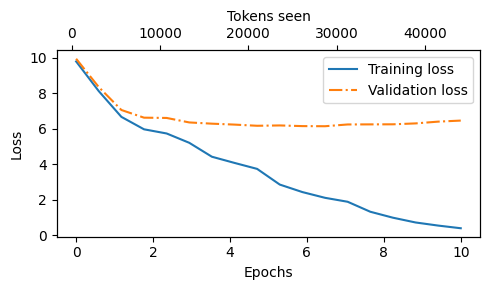

In [48]:
# Plot the training and validation losses
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator


def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    fig, ax1 = plt.subplots(figsize=(5, 3))

    # Plot training and validation loss against epochs
    ax1.plot(epochs_seen, train_losses, label="Training loss")
    ax1.plot(epochs_seen, val_losses, linestyle="-.", label="Validation loss")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))  # only show integer labels on x-axis

    # Create a second x-axis for tokens seen
    ax2 = ax1.twiny()  # Create a second x-axis that shares the same y-axis
    ax2.plot(tokens_seen, train_losses, alpha=0)  # Invisible plot for aligning ticks
    ax2.set_xlabel("Tokens seen")

    fig.tight_layout()  # Adjust layout to make room
    plt.savefig("loss-plot.pdf")
    plt.show()

epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)

**Notes**

the training loss is gradually dropping, whereas the validation loss has deviated and have become constant after a few epoch. It means, the model is overfitting. It is sensitive to the training data.

## Save the Trained Model Checkpoint
Here I am saving the model so that I do not have to retrain it in subsequent chapters. I will simply load it and use.

In [ ]:
torch.save({
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    }, 
    "./checkpoints/gpt2-pretrained.pth"
)